In [4]:
# 1. Gerekli Kütüphanelerin Kurulumu (Terminalde hata almamak için)
# 'imblearn' kütüphanesi yüklü değilse kullanıcıyı bilgilendiriyoru
try:
    from imblearn.ensemble import BalancedBaggingClassifier
except ImportError:
    print("imblearn kütüphanesi yükleniyor...")
    

import pandas as pd     # Veri tablolarını (DataFrame) yönetmek için
import numpy as np      # Matematiksel ve matris işlemleri için
import matplotlib.pyplot as plt  # Grafik çizimleri için
import seaborn as sns   # Gelişmiş istatistiksel görselleştirme için
import warnings         # Sistem uyarılarını yönetmek için

# Modeller ve Metrikler
from sklearn.model_selection import train_test_split # Veriyi eğitim ve test olarak ikiye bölmek için kullanılır
from sklearn.ensemble import HistGradientBoostingClassifier #eksik verilere duyarlı güçlü bir sınıflandırıcı
from imblearn.ensemble import BalancedBaggingClassifier # Dengesiz veri setleri için özel olarak tasarlanmış ensemble modeli
from sklearn.tree import DecisionTreeClassifier # Temel karar ağacı algoritması
from sklearn.metrics import (confusion_matrix, roc_curve, auc, 
                             f1_score, accuracy_score, recall_score, precision_score) # Modellerin başarısını ölçmek için kullanılan temel performans metrikleri

# Uyarıları ve gereksiz kalabalığı kapat
warnings.filterwarnings('ignore')

In [5]:
# 1. Veri Yükleme
df = pd.read_csv('diabetic_data_processed.csv')
X = df.drop('target', axis=1)
y = df['target']

In [6]:
# 2. Veri Bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# 3. Model Tanımlamaları
# Karşılaştırılacak algoritmaları bir sözlük yapısında saklıyorum.
# Bu sayede döngü kullanarak tüm modelleri otomatik olarak eğitebilirim.
models = {
    # Hist-Gradient Boosting: Büyük verilerde hızlı çalışan ve eksik verileri (NaN) 
    # doğrudan işleyebilen, gradyan artırma tabanlı güçlü bir modeldir.
    "Hist-Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300,  # Maksimum 300 ağaç (iterasyon) oluşturur.
        learning_rate=0.05, 
        class_weight='balanced',  # Verideki dengesizliğini otomatik telafi eder.
        random_state=42
    ),
    # Balanced Bagging: Dengesiz veri setleri için özel geliştirilmiştir.
    # Her bir alt örneklemde sınıfları dengeler
    "Balanced Bagging": BalancedBaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=10, class_weight='balanced'),
        n_estimators=100, # 100 farklı ağaç oluşturup sonuçları birleştirir.
        random_state=42
    )
}

# Sonuçları saklamak için
results_list = []
prob_dict = {}

In [ ]:
# 4. Eğitim ve Tahmin
for name, model in models.items():
    print(f">> {name} eğitiliyor...")
    # Modeli eğitim verisiyle eğit
    model.fit(X_train, y_train)
    # Test verisi üzerinde tahminleri ve olasılık değerlerini hesaplanır
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    prob_dict[name] = y_proba
    
    # Metrikleri listeye ekle
    results_list.append({
        'Model': name,
        'Doğruluk (Accuracy)': accuracy_score(y_test, y_pred),
        'Hassasiyet (Precision)': precision_score(y_test, y_pred),
        'Duyarlılık (Recall)': recall_score(y_test, y_pred),
        'F1-Skoru': f1_score(y_test, y_pred),
        'AUC-ROC': auc(*roc_curve(y_test, y_proba)[:2])
    })



>> Hist-Gradient Boosting eğitiliyor...
>> Balanced Bagging eğitiliyor...


<Figure size 1800x1000 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

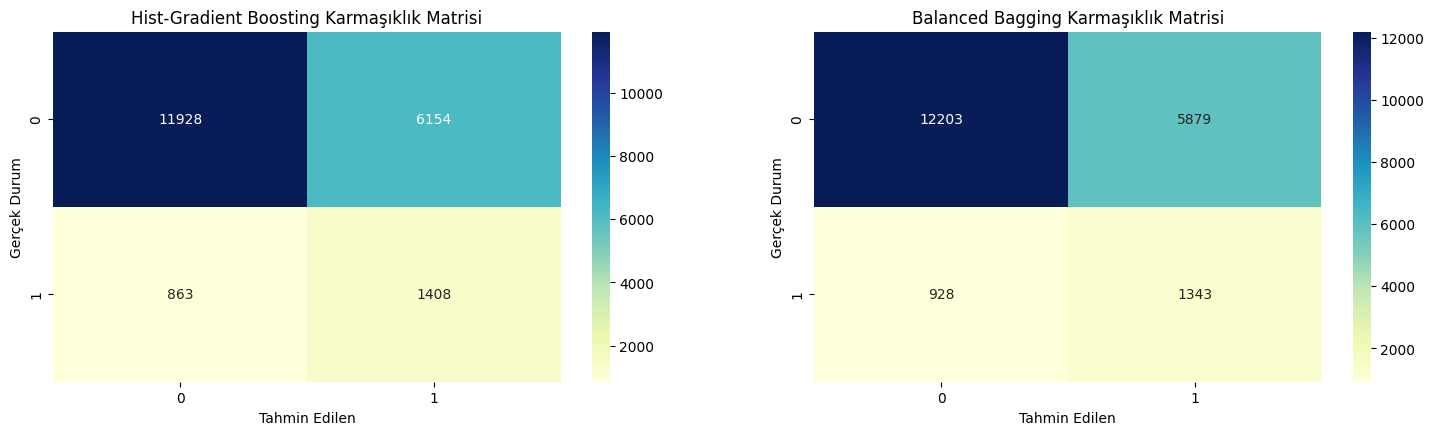

In [17]:
# --- GÖRSELLEŞTİRME ---
plt.figure(figsize=(18, 10))
# A. Karmaşıklık Matrisleri
for i, name in enumerate(models.keys()):
    plt.subplot(2, 2, i+1) # Matrisleri yan yana/alt alta düzenle
    
    # Olasılık değerlerini 0.5 eşiğine göre sınıflandır ve matrisi oluştur
    y_pred = (prob_dict[name] > 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    
    # Matrisi ısı haritası (heatmap) olarak çizdir
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'{name} Karmaşıklık Matrisi')
    plt.xlabel('Tahmin Edilen')
    plt.ylabel('Gerçek Durum')


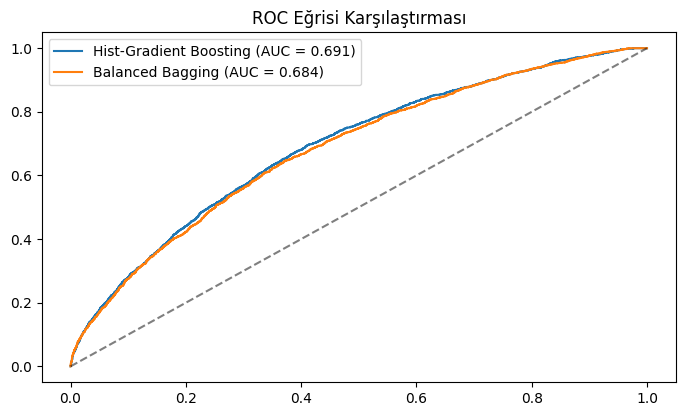

In [19]:
# --- GÖRSELLEŞTİRME ---
plt.figure(figsize=(18, 10))
# B. ROC Eğrisi
plt.subplot(2, 2, 3)
for name, y_proba in prob_dict.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('ROC Eğrisi Karşılaştırması')
plt.legend()

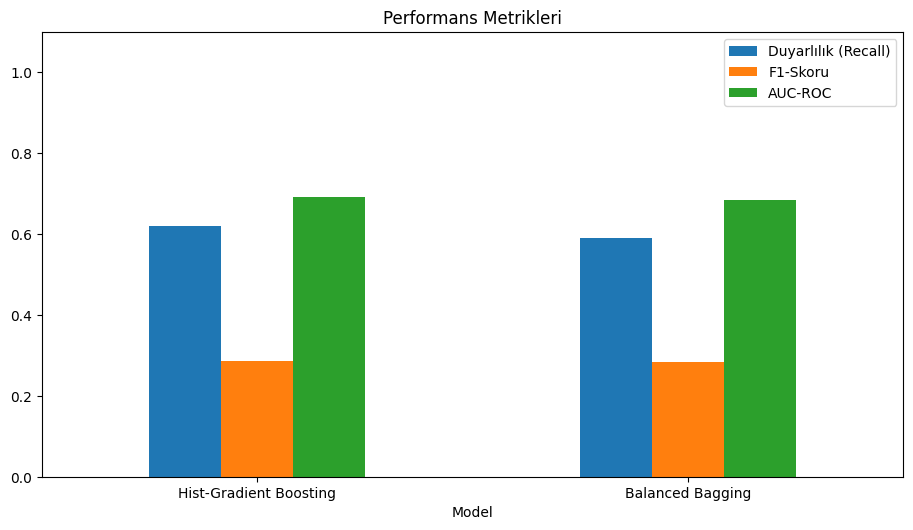

In [21]:
# --- GÖRSELLEŞTİRME ---
plt.figure(figsize=(18, 10))
# C. Model Metrik Karşılaştırma Grafiği
plt.subplot(2, 2, 4)
temp_df = pd.DataFrame(results_list).set_index('Model')
temp_df[['Duyarlılık (Recall)', 'F1-Skoru', 'AUC-ROC']].plot(kind='bar', ax=plt.gca())
plt.title('Performans Metrikleri')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [22]:
# --- GERÇEK TABLO GÖRÜNÜMÜ ---
# VS Code .ipynb içinde bu kısım şık bir tablo olarak görünecektir.
final_df = pd.DataFrame(results_list).set_index('Model')
display(final_df.style.background_gradient(cmap='Blues').format(precision=4))

,Doğruluk (Accuracy),Hassasiyet (Precision),Duyarlılık (Recall),F1-Skoru,AUC-ROC
Model,,,,,
Hist-Gradient Boosting,0.6552,0.1862,0.6200,0.2864,0.6907
Balanced Bagging,0.6656,0.1860,0.5914,0.2829,0.6839


In [23]:
# --- EN İYİ MODELİN SEÇİLMESİ VE ÖZETİ ---

# Karşılaştırma kriteri olarak F1-Skoru'nu seçiyoruz (Sağlıkta dengesiz veri için en güvenilir metrik)
best_model_name = final_df['F1-Skoru'].idxmax()
best_f1 = final_df.loc[best_model_name, 'F1-Skoru']
best_recall = final_df.loc[best_model_name, 'Duyarlılık (Recall)']

print("\n" + "="*60)
print(" ŞAMPİYON MODEL ANALİZİ ")
print("="*60)
print(f"Sistem tarafından seçilen en iyi model: {best_model_name}")
print(f"F1-Skoru Başarısı: {best_f1:.4f}")
print(f"Duyarlılık (Recall) Başarısı: {best_recall:.4f}")
print("-"*60)

# Seçim nedenini açıklayan bir not
print(f"NOT: '{best_model_name}' modeli, hem kesinlik hem de duyarlılık dengesini ")
print("temsil eden F1-Skoru baz alınarak en başarılı model olarak belirlenmiştir.")

if best_recall < 0.5:
    print(" UYARI: Modelin duyarlılık (recall) skoru düşük. Yüksek riskli hastaları ")
    print("yakalamak için eşik değerleri (threshold) üzerinde çalışılması önerilir.")
else:
    print(" Bu model, yüksek riskli hastaları tespit etmede makul bir performans sergilemektedir.")

print("="*60)


 ŞAMPİYON MODEL ANALİZİ 
Sistem tarafından seçilen en iyi model: Hist-Gradient Boosting
F1-Skoru Başarısı: 0.2864
Duyarlılık (Recall) Başarısı: 0.6200
------------------------------------------------------------
NOT: 'Hist-Gradient Boosting' modeli, hem kesinlik hem de duyarlılık dengesini 
temsil eden F1-Skoru baz alınarak en başarılı model olarak belirlenmiştir.
 Bu model, yüksek riskli hastaları tespit etmede makul bir performans sergilemektedir.


In [24]:
import joblib

# 1. Sözlükten şampiyon model nesnesini alalım

champion_model_obj = models[best_model_name]

# 2. Modeli dosya olarak kaydedelim 
model_file = "Hist_Gradient_Boosting.pkl"
joblib.dump(champion_model_obj, model_file)

# 3. Eğer veriyi ölçeklendirdik (StandardScaler gibi), 
# tahmin yaparken yeni veriyi de aynı şekilde ölçeklendirmek için scaler'ı da kaydetmeliyiz.
try:
    if 'scaler' in locals() or 'scaler' in globals():
        joblib.dump(scaler, "scaler_modeli.pkl")
        print("Model ve Ölçeklendirici (Scaler) başarıyla kaydedildi.")
    else:
        print(f"'{best_model_name}' başarıyla '{model_file}' adıyla kaydedildi.")
except NameError:
    print(f"'{best_model_name}' başarıyla '{model_file}' adıyla kaydedildi.")

print("="*60)

'Hist-Gradient Boosting' başarıyla 'Hist_Gradient_Boosting.pkl' adıyla kaydedildi.
